# Stage 1 sweep analysis

Reusable analysis notebook for Stage 1 sweeps. Set `FEATURE_MODE` to `koppen`, `raw`, or `pca` and rerun the notebook.

This notebook reports:

- top 5 configurations by lowest mean fitness,
- top 5 configurations by mean weighted ecological consistency,
- mean fitness and ecological consistency by algorithm and by parameter value,
- distributions of fitness and ecological consistency overall, by algorithm, and by parameter value,
- optional exports of the main analysis tables.

In [26]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

FEATURE_MODE = "koppen"  # "koppen", "raw", or "pca"
FITNESS_MODE = "silhouette"
RESULTS_ROOT = Path(f"../experiments/results")
BASE_DIR = RESULTS_ROOT / FEATURE_MODE / FITNESS_MODE
SUMMARY_PATH = BASE_DIR / "stage1_sweep_summary.csv"
RUNS_PATH = BASE_DIR / "stage1_sweep_runs.csv"
OUTPUT_DIR = BASE_DIR / "analysis_outputs"

TOP_N = 5
N_BINS = 20

FITNESS_COL = "mean_best_fitness"
ECO_COL = "mean_weighted_combined_ecological_consistency"
OTHER_FUNCTION_1 = "mean_centroid_fitness"
OTHER_FUNCTION_2 = "mean_snn_fitness"
ARI_COL = "mean_ari_vs_kmeans"

RUN_FITNESS_COL = "best_fitness"
RUN_ECO_COL = "weighted_combined_ecological_consistency"
RUN_ARI_COL = "ari_vs_kmeans"

PARAM_COLS = ["algorithm", "pheromone_update", "alpha", "beta", "evaporation", "q"]
CONFIG_COLS = ["algorithm", "pheromone_update", "alpha", "beta", "evaporation", "q", "feature_mode", "mode"]

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)
plt.style.use("default")

## 1. Load data

In [18]:
def read_csv_auto(path):
    if not path.exists():
        raise FileNotFoundError(path)
    try:
        df = pd.read_csv(path, sep=";")
        if df.shape[1] > 1:
            return df
    except pd.errors.ParserError:
        pass
    return pd.read_csv(path)

summary = read_csv_auto(SUMMARY_PATH)
runs = read_csv_auto(RUNS_PATH)

print("Feature mode:", FEATURE_MODE)
print("Summary path:", SUMMARY_PATH)
print("Runs path:", RUNS_PATH)
print("Summary rows:", len(summary), "columns:", len(summary.columns))
print("Run rows:", len(runs), "columns:", len(runs.columns))
display(summary.head())

Feature mode: koppen
Summary path: ../experiments/results/koppen/silhouette/stage1_sweep_summary.csv
Runs path: ../experiments/results/koppen/silhouette/stage1_sweep_runs.csv
Summary rows: 252 columns: 42
Run rows: 504 columns: 47


,fitness_name,algorithm,pheromone_update,alpha,beta,evaporation,q,feature_mode,mode,mean_best_fitness,std_best_fitness,best_best_fitness,mean_recomputed_fitness,std_recomputed_fitness,best_recomputed_fitness,mean_centroid_fitness,std_centroid_fitness,mean_silhouette_fitness,std_silhouette_fitness,mean_snn_fitness,std_snn_fitness,mean_silhouette,std_silhouette,mean_silhouette_term,std_silhouette_term,mean_spatial,std_spatial,mean_ari_vs_kmeans,std_ari_vs_kmeans,mean_weighted_combined_ecological_consistency,std_weighted_combined_ecological_consistency,best_weighted_combined_ecological_consistency,mean_mean_combined_ecological_consistency,std_mean_combined_ecological_consistency,mean_weighted_agriculture_homogeneity,std_weighted_agriculture_homogeneity,mean_weighted_natural_homogeneity,std_weighted_natural_homogeneity,mean_weighted_artificial_share_total,std_weighted_artificial_share_total,mean_runtime_sec,std_runtime_sec
0,silhouette,aco_centroid_refinement,all_ants,0.75,1.0,0.10,0.05,koppen,superpixels,0.363225,0.004630,0.359951,0.363225,0.004630,0.359951,0.267587,0.005801,0.363225,0.004630,0.217546,0.014631,0.285136,0.002196,0.357432,0.001098,0.376742,0.017994,0.641419,0.059970,0.483073,0.001807,0.484350,0.476721,0.002457,0.413378,0.000715,0.486600,0.000455,0.037975,0.000004,71.910849,0.151060
1,silhouette,aco_centroid_refinement,all_ants,0.75,1.0,0.02,0.05,koppen,superpixels,0.369337,0.004616,0.366073,0.369337,0.004616,0.366073,0.271083,0.010276,0.369337,0.004616,0.220750,0.019933,0.271260,0.003309,0.364370,0.001654,0.380926,0.019248,0.646905,0.048889,0.482503,0.002060,0.483959,0.476482,0.002873,0.413004,0.001868,0.483330,0.000006,0.037980,0.000029,72.175352,0.225082
2,silhouette,aco_centroid_refinement,all_ants,0.75,3.0,0.10,0.05,koppen,superpixels,0.334846,0.003137,0.332627,0.334846,0.003137,0.332627,0.243636,0.002333,0.334846,0.003137,0.173201,0.000191,0.334955,0.007887,0.332523,0.003944,0.340266,0.001254,0.737991,0.011892,0.482370,0.004643,0.485653,0.481200,0.003152,0.419067,0.005751,0.487823,0.000554,0.037964,0.000019,72.215009,0.108409
3,silhouette,aco_centroid_refinement,all_ants,0.75,3.0,0.02,0.05,koppen,superpixels,0.335130,0.002800,0.333150,0.335130,0.002800,0.333150,0.246734,0.006672,0.335130,0.002800,0.175365,0.002315,0.336221,0.009679,0.331889,0.004839,0.342692,0.001958,0.715818,0.030515,0.480484,0.006652,0.485188,0.480174,0.003757,0.416662,0.008781,0.487206,0.001092,0.037959,0.000010,72.187472,0.078412
4,silhouette,aco_centroid_refinement,all_ants,1.00,1.0,0.02,0.05,koppen,superpixels,0.357488,0.014745,0.347061,0.357488,0.014745,0.347061,0.259796,0.009746,0.357488,0.014745,0.190696,0.005998,0.280022,0.040904,0.359989,0.020452,0.351652,0.001430,0.637282,0.004719,0.480246,0.001379,0.481221,0.475652,0.005041,0.418118,0.011217,0.483248,0.002651,0.037983,0.000041,71.905530,0.117814


## 2. Basic checks

In [19]:
required_summary_cols = CONFIG_COLS + [FITNESS_COL, ECO_COL, ARI_COL]
required_run_cols = CONFIG_COLS + ["seed", RUN_FITNESS_COL, RUN_ECO_COL, RUN_ARI_COL]

missing_summary = [c for c in required_summary_cols if c not in summary.columns]
missing_runs = [c for c in required_run_cols if c not in runs.columns]
if missing_summary:
    raise ValueError(f"Missing summary columns: {missing_summary}")
if missing_runs:
    raise ValueError(f"Missing run columns: {missing_runs}")

summary = summary.dropna(subset=[FITNESS_COL, ECO_COL]).copy()
runs = runs.dropna(subset=[RUN_FITNESS_COL, RUN_ECO_COL]).copy()

for df in [summary, runs]:
    for col in ["alpha", "beta", "evaporation", "q"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Feature modes in summary:", sorted(summary["feature_mode"].unique()))
print("Algorithms:", sorted(summary["algorithm"].unique()))
print("Pheromone updates:", sorted(summary["pheromone_update"].unique()))
print("Seeds in runs:", sorted(runs["seed"].unique()))

Feature modes in summary: ['koppen']
Algorithms: ['aco_centroid', 'aco_centroid_refinement', 'aco_cohesion', 'aco_cohesion_refinement', 'aco_graph_local', 'multi_centroid_graph_spatial', 'multi_cohesion_graph_spatial']
Pheromone updates: ['all_ants', 'best_ant', 'quality_weighted']
Seeds in runs: [0, 1]


## 3. Helper functions

In [20]:
def metric_direction(col):
    if "fitness" in col:
        return "lower_is_better"
    if "ecological" in col or "eco" in col:
        return "higher_is_better"
    return "unspecified"


def describe_metric(data, col):
    s = data[col]
    direction = metric_direction(col)
    min_value = s.min()
    max_value = s.max()
    return pd.Series({
        "direction": direction,
        "count": s.count(),
        "mean": s.mean(),
        "std": s.std(),
        "worst": max_value if direction == "lower_is_better" else min_value,
        "p25": s.quantile(0.25),
        "median": s.median(),
        "p75": s.quantile(0.75),
        "best": min_value if direction == "lower_is_better" else max_value,
        "min": min_value,
        "max": max_value,
        "range": max_value - min_value,
    })


def distribution_table(data, metric_cols):
    return pd.DataFrame([describe_metric(data, c).rename(c) for c in metric_cols]).reset_index().rename(columns={"index": "metric"})


def grouped_distribution(data, group_col, metric_cols):
    rows = []
    for value, subset in data.groupby(group_col, dropna=False):
        dist = distribution_table(subset, metric_cols)
        dist.insert(0, "value", value)
        dist.insert(0, "group", group_col)
        rows.append(dist)
    return pd.concat(rows, ignore_index=True)


def mean_by_group(data, group_col):
    return (
        data.groupby(group_col, dropna=False)
        .agg(
            configs=(group_col, "size"),
            mean_fitness=(FITNESS_COL, "mean"),
            std_fitness=(FITNESS_COL, "std"),
            mean_eco=(ECO_COL, "mean"),
            std_eco=(ECO_COL, "std"),
            min_fitness=(FITNESS_COL, "min"),
            max_eco=(ECO_COL, "max"),
        )
        .reset_index()
        .sort_values("mean_fitness", ascending=True)
    )


def plot_hist(data, col, title, bins=N_BINS):
    ax = data[col].hist(bins=bins, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    plt.show()


def plot_box_by_group(data, col, group_col, title):
    order = sorted(data[group_col].dropna().unique())
    ax = data.boxplot(column=col, by=group_col, rot=45, grid=False, figsize=(10, 4))
    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel(col)
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

## 4. Top 5 configurations

In [21]:
display_cols = CONFIG_COLS + [
    FITNESS_COL,
    "std_best_fitness",
    "best_best_fitness",
    ECO_COL,
    "std_weighted_combined_ecological_consistency",
    "best_weighted_combined_ecological_consistency",
    ARI_COL,
    "mean_compactness",
    "mean_spatial",
]
display_cols = [c for c in display_cols if c in summary.columns]

top_by_fitness = summary.sort_values([FITNESS_COL, ECO_COL], ascending=[True, False]).head(TOP_N)[display_cols]
top_by_ecology = summary.sort_values([ECO_COL, FITNESS_COL], ascending=[False, True]).head(TOP_N)[display_cols]

print(f"Top {TOP_N} by lowest mean fitness")
display(top_by_fitness)

print(f"Top {TOP_N} by mean weighted ecological consistency")
display(top_by_ecology)

Top 5 by lowest mean fitness


,algorithm,pheromone_update,alpha,beta,evaporation,q,feature_mode,mode,mean_best_fitness,std_best_fitness,best_best_fitness,mean_weighted_combined_ecological_consistency,std_weighted_combined_ecological_consistency,best_weighted_combined_ecological_consistency,mean_ari_vs_kmeans,mean_spatial
176,multi_centroid_graph_spatial,quality_weighted,2.0,3.0,0.02,0.05,koppen,superpixels,0.267159,0.014566,0.256859,0.427363,0.001679,0.428550,0.306188,0.196444
183,multi_centroid_graph_spatial,all_ants,2.0,3.0,0.10,0.05,koppen,superpixels,0.269712,0.016222,0.258241,0.420810,0.010092,0.427947,0.282195,0.190829
182,multi_centroid_graph_spatial,all_ants,2.0,3.0,0.02,0.05,koppen,superpixels,0.270301,0.015164,0.259579,0.420837,0.010023,0.427924,0.282426,0.197066
134,multi_centroid_graph_spatial,best_ant,2.0,3.0,0.02,0.05,koppen,superpixels,0.279570,0.002575,0.277749,0.440293,0.016302,0.451820,0.413802,0.254107
178,multi_centroid_graph_spatial,quality_weighted,2.0,3.0,0.10,0.05,koppen,superpixels,0.285298,0.011430,0.277216,0.425608,0.004824,0.429019,0.327900,0.223930


Top 5 by mean weighted ecological consistency


,algorithm,pheromone_update,alpha,beta,evaporation,q,feature_mode,mode,mean_best_fitness,std_best_fitness,best_best_fitness,mean_weighted_combined_ecological_consistency,std_weighted_combined_ecological_consistency,best_weighted_combined_ecological_consistency,mean_ari_vs_kmeans,mean_spatial
0,aco_centroid_refinement,all_ants,0.75,1.0,0.10,0.05,koppen,superpixels,0.363225,0.004630,0.359951,0.483073,0.001807,0.484350,0.641419,0.376742
1,aco_centroid_refinement,all_ants,0.75,1.0,0.02,0.05,koppen,superpixels,0.369337,0.004616,0.366073,0.482503,0.002060,0.483959,0.646905,0.380926
2,aco_centroid_refinement,all_ants,0.75,3.0,0.10,0.05,koppen,superpixels,0.334846,0.003137,0.332627,0.482370,0.004643,0.485653,0.737991,0.340266
3,aco_centroid_refinement,all_ants,0.75,3.0,0.02,0.05,koppen,superpixels,0.335130,0.002800,0.333150,0.480484,0.006652,0.485188,0.715818,0.342692
4,aco_centroid_refinement,all_ants,1.00,1.0,0.02,0.05,koppen,superpixels,0.357488,0.014745,0.347061,0.480246,0.001379,0.481221,0.637282,0.351652


## 5. Mean fitness and ecology by algorithm and parameters

In [22]:
parameter_means = []
for param in PARAM_COLS:
    print(f"By {param}")
    table = mean_by_group(summary, param).rename(columns={param: "value"})
    # table.insert(0, "parameter", param)
    parameter_means.append(table)
    display(table)
parameter_means = pd.concat(parameter_means, ignore_index=True)

# display(parameter_means)

By algorithm


,value,configs,mean_fitness,std_fitness,mean_eco,std_eco,min_fitness,max_eco
0,aco_centroid,36,0.333978,0.038817,0.463783,0.007663,0.287792,0.479134
5,multi_centroid_graph_spatial,36,0.341954,0.057537,0.436908,0.006823,0.267159,0.457926
1,aco_centroid_refinement,36,0.384308,0.069610,0.462242,0.018346,0.308440,0.483073
4,aco_graph_local,36,0.425018,0.091307,0.428081,0.015059,0.309042,0.450325
6,multi_cohesion_graph_spatial,36,0.448401,0.109912,0.428412,0.019782,0.296797,0.471066
3,aco_cohesion_refinement,36,0.482017,0.129305,0.428134,0.031949,0.310029,0.473542
2,aco_cohesion,36,0.483187,0.127073,0.423087,0.027341,0.309044,0.464647


By pheromone_update


,value,configs,mean_fitness,std_fitness,mean_eco,std_eco,min_fitness,max_eco
0,all_ants,84,0.408844,0.108167,0.443028,0.027332,0.269712,0.483073
2,quality_weighted,84,0.415948,0.111103,0.437764,0.024809,0.267159,0.476115
1,best_ant,84,0.417578,0.111878,0.435200,0.023696,0.279570,0.468784


By alpha


...

,value,configs,mean_fitness,std_fitness,mean_eco,std_eco,min_fitness,max_eco
1,3.0,126,0.331086,0.034136,0.451707,0.013445,0.267159,0.482370
0,1.0,126,0.497161,0.096120,0.425621,0.027843,0.341342,0.483073


By evaporation


,value,configs,mean_fitness,std_fitness,mean_eco,std_eco,min_fitness,max_eco
1,0.10,126,0.413495,0.109628,0.438728,0.025381,0.269712,0.483073
0,0.02,126,0.414752,0.110842,0.438600,0.025588,0.267159,0.482503


By q


,value,configs,mean_fitness,std_fitness,mean_eco,std_eco,min_fitness,max_eco
0,0.05,252,0.414123,0.110019,0.438664,0.025434,0.267159,0.483073


## 6. Overall distributions

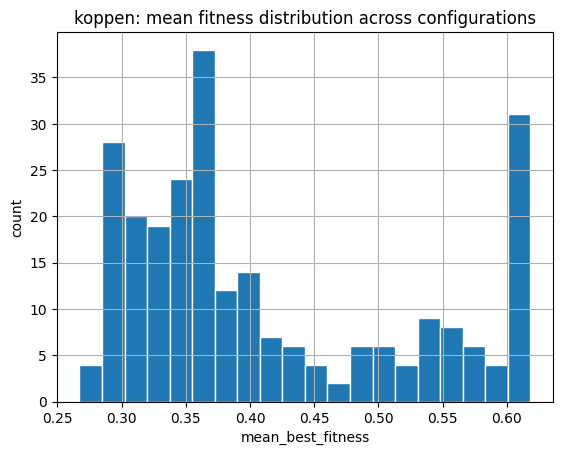

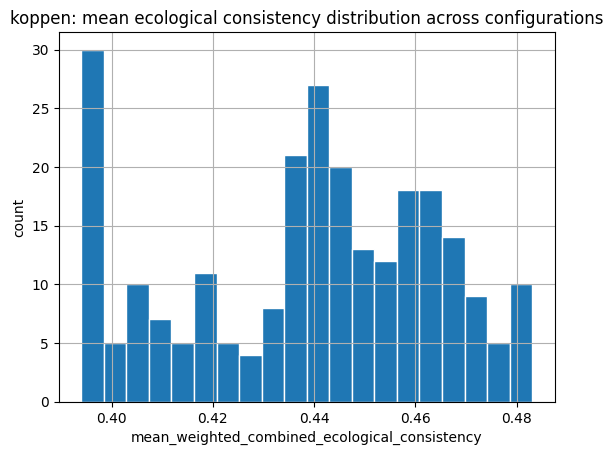

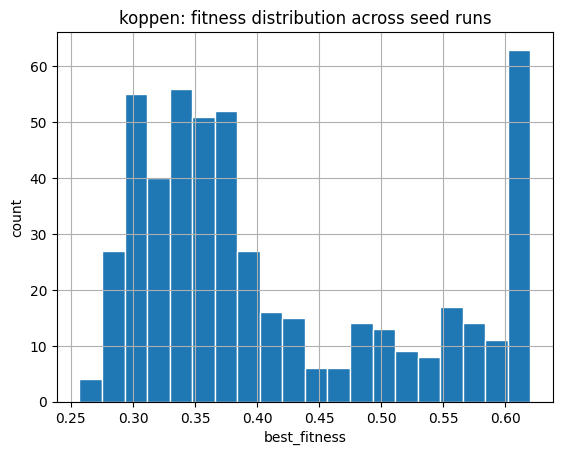

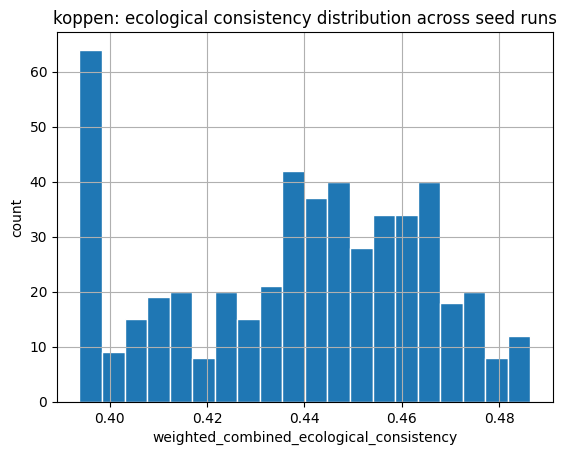

In [29]:
plot_hist(summary, FITNESS_COL, f"{FEATURE_MODE}: mean fitness distribution across configurations")
plot_hist(summary, ECO_COL, f"{FEATURE_MODE}: mean ecological consistency distribution across configurations")
plot_hist(runs, RUN_FITNESS_COL, f"{FEATURE_MODE}: fitness distribution across seed runs")
plot_hist(runs, RUN_ECO_COL, f"{FEATURE_MODE}: ecological consistency distribution across seed runs")

## 7. Distributions by algorithm

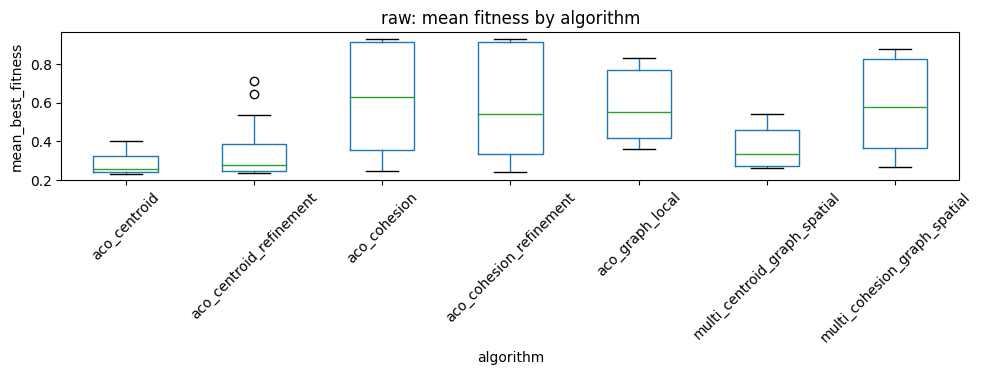

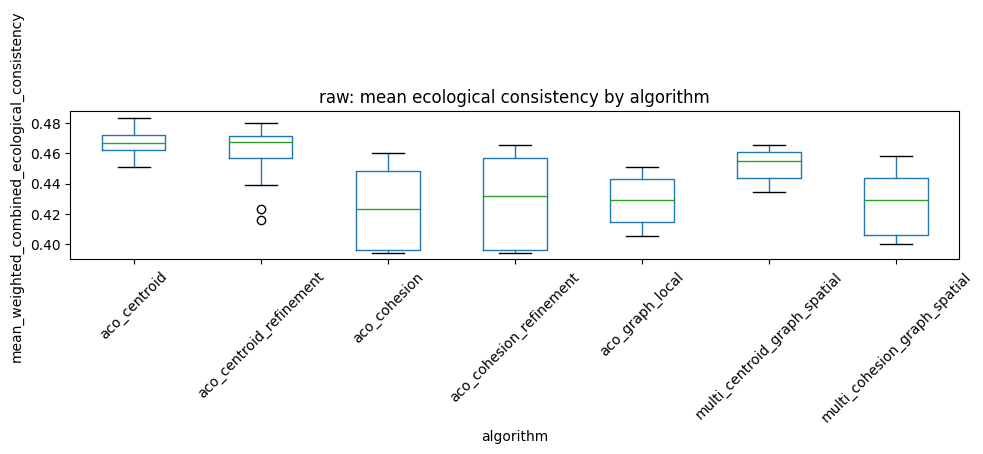

In [17]:
plot_box_by_group(summary, FITNESS_COL, "algorithm", f"{FEATURE_MODE}: mean fitness by algorithm")
plot_box_by_group(summary, ECO_COL, "algorithm", f"{FEATURE_MODE}: mean ecological consistency by algorithm")

## 8. Distributions by parameter value

===== pheromone_update =====


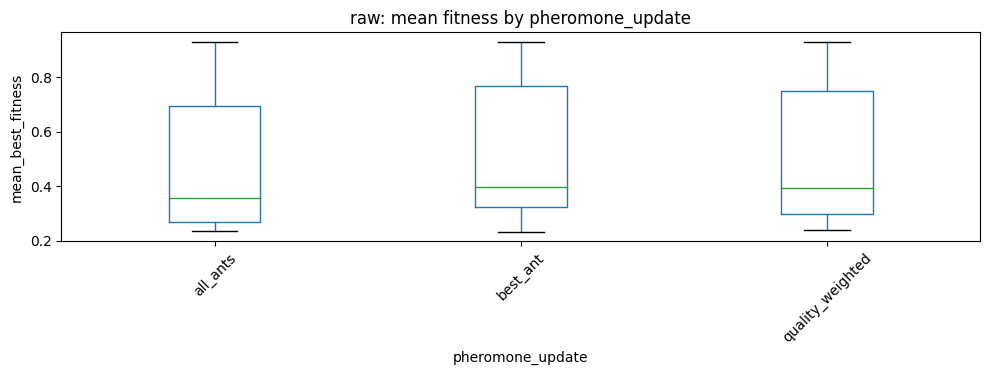

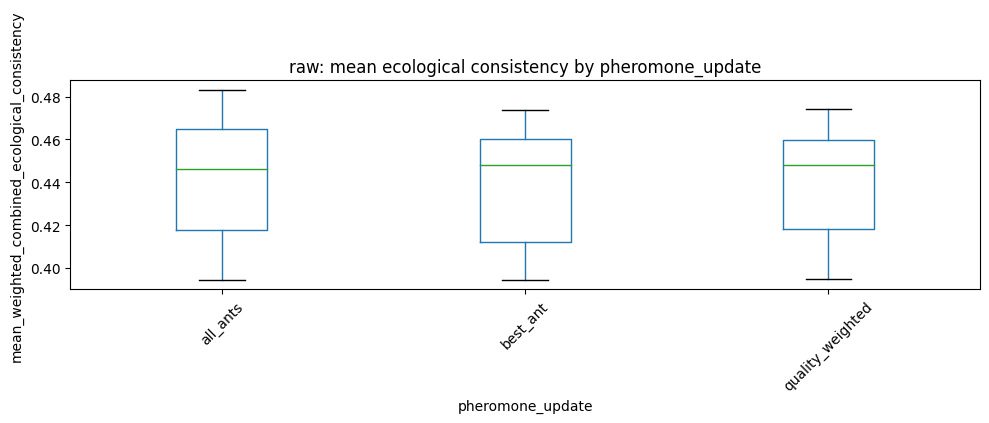

===== alpha =====


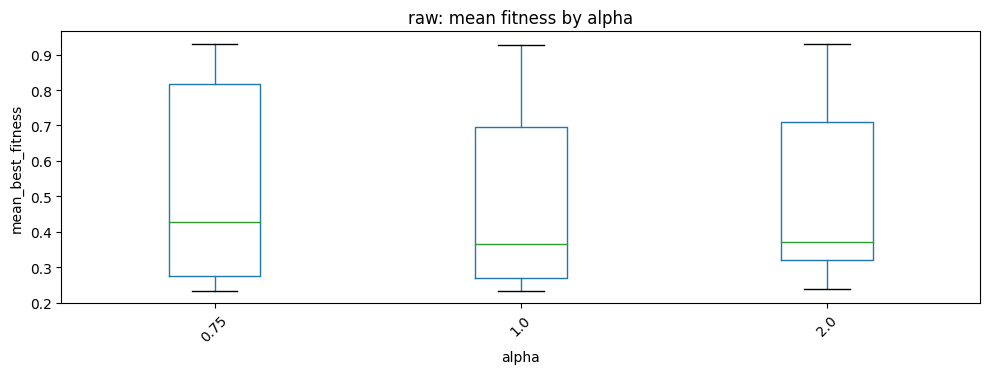

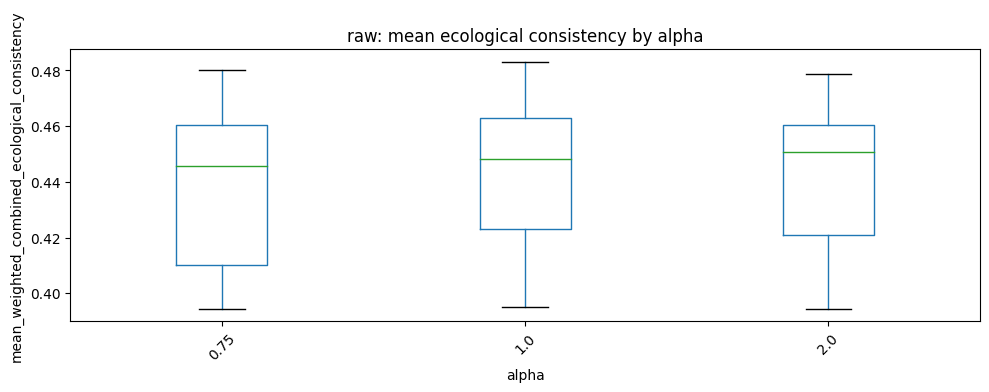

===== beta =====


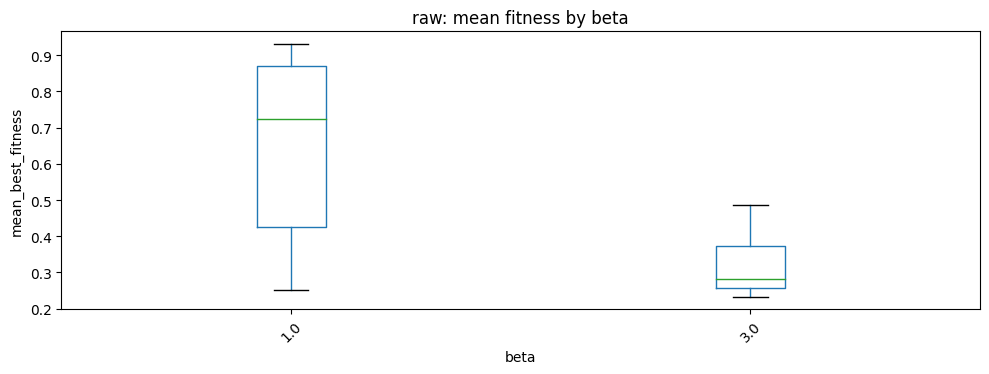

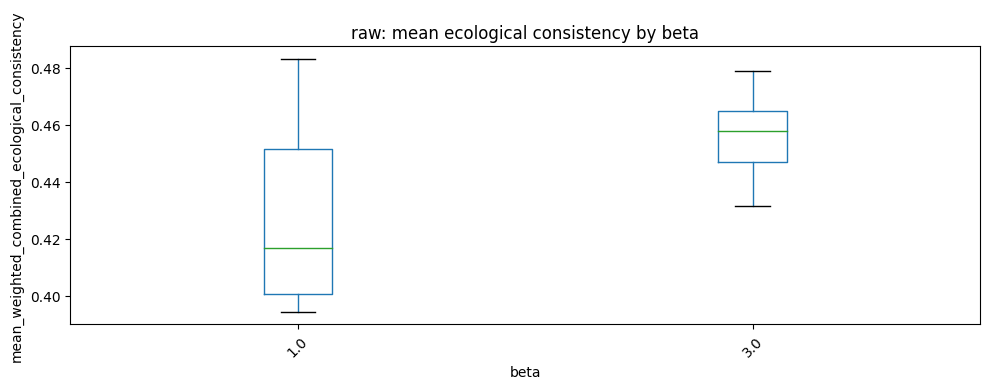

===== evaporation =====


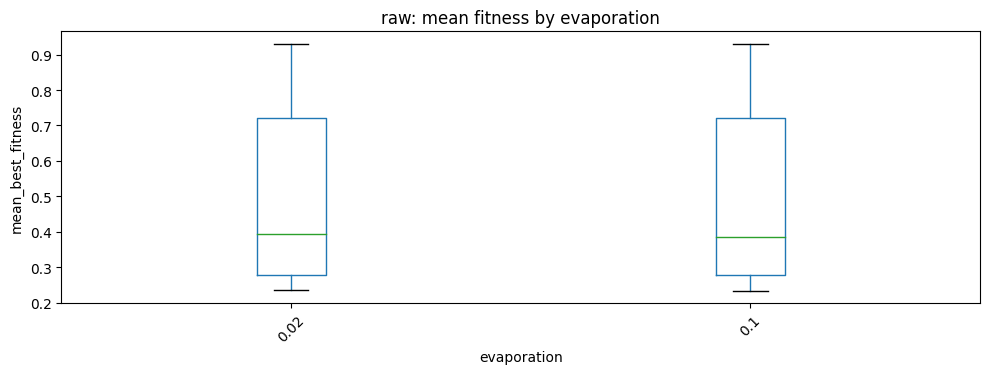

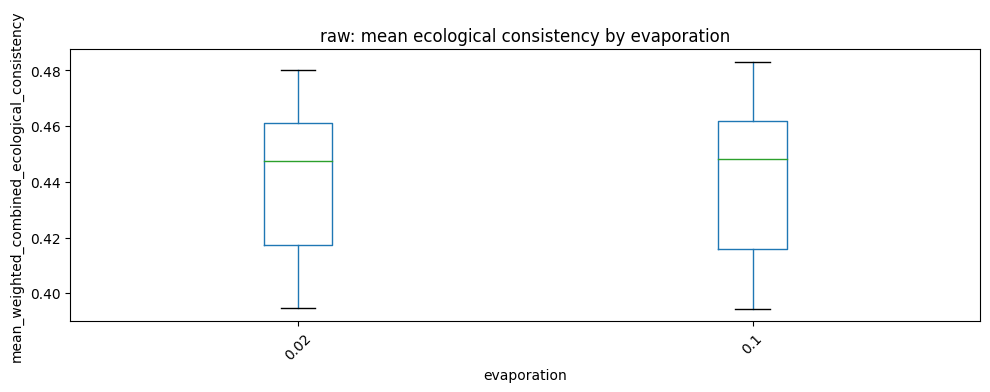

===== q =====


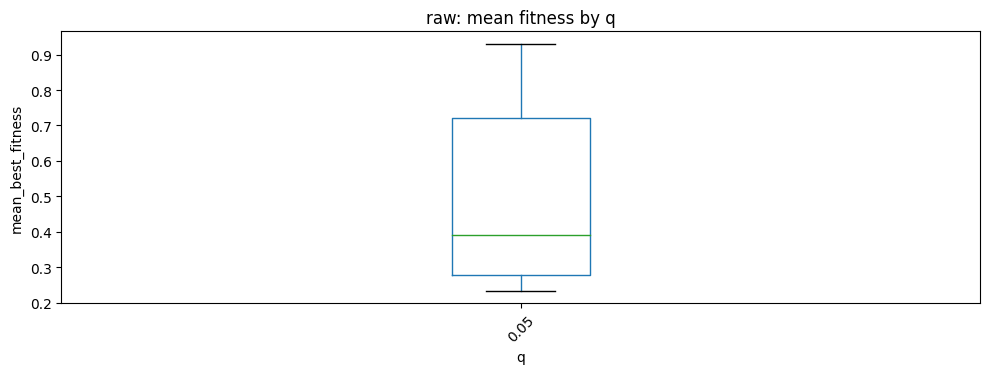

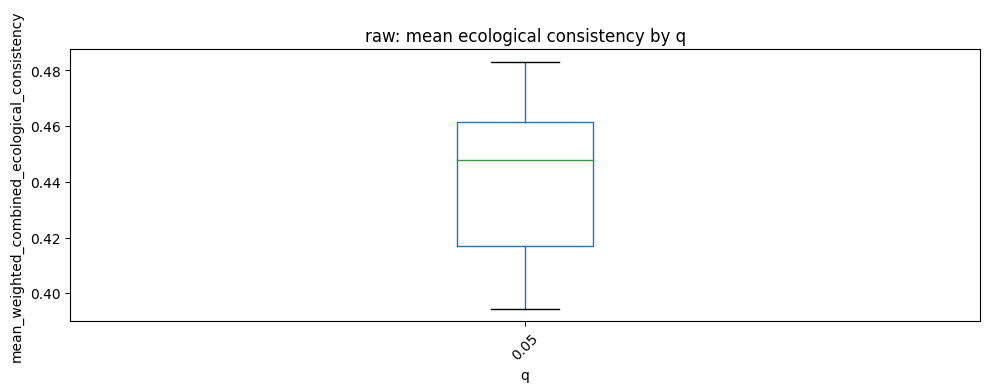

In [19]:
for param in ["pheromone_update", "alpha", "beta", "evaporation", "q"]:
    print(f"===== {param} =====")
    plot_box_by_group(summary, FITNESS_COL, param, f"{FEATURE_MODE}: mean fitness by {param}")
    plot_box_by_group(summary, ECO_COL, param, f"{FEATURE_MODE}: mean ecological consistency by {param}")

## 9. Fitness vs ecology

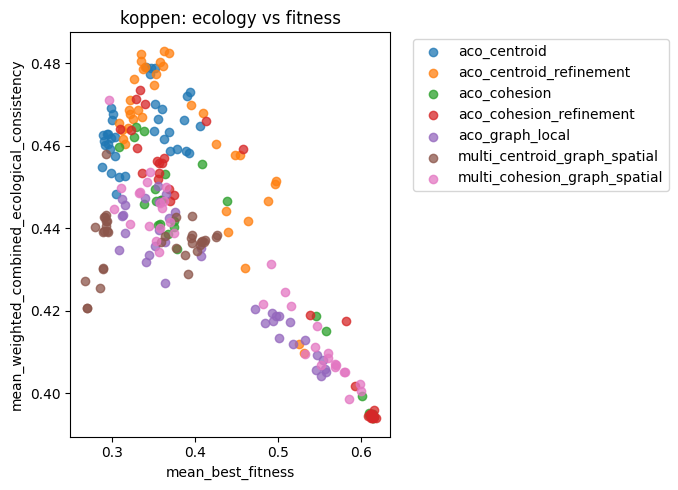

Pearson correlation


,mean_best_fitness,mean_weighted_combined_ecological_consistency,mean_ari_vs_kmeans
mean_best_fitness,1.000000,-0.828316,-0.877479
mean_weighted_combined_ecological_consistency,-0.828316,1.000000,0.987241
mean_ari_vs_kmeans,-0.877479,0.987241,1.000000


Spearman correlation


,mean_best_fitness,mean_weighted_combined_ecological_consistency,mean_ari_vs_kmeans
mean_best_fitness,1.000000,-0.677265,-0.734414
mean_weighted_combined_ecological_consistency,-0.677265,1.000000,0.982056
mean_ari_vs_kmeans,-0.734414,0.982056,1.000000


In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
for algorithm, subset in summary.groupby("algorithm"):
    ax.scatter(subset[FITNESS_COL], subset[ECO_COL], label=algorithm, alpha=0.75)
ax.set_xlabel(FITNESS_COL)
ax.set_ylabel(ECO_COL)
ax.set_title(f"{FEATURE_MODE}: ecology vs fitness")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Pearson correlation")
display(summary[[FITNESS_COL, ECO_COL, ARI_COL]].corr(method="pearson"))
print("Spearman correlation")
display(summary[[FITNESS_COL, ECO_COL, ARI_COL]].corr(method="spearman"))

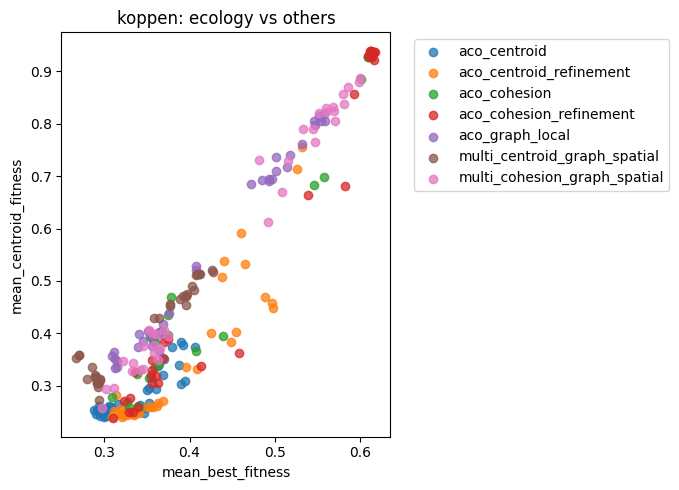

Pearson correlation


,mean_best_fitness,mean_centroid_fitness,mean_ari_vs_kmeans
mean_best_fitness,1.000000,0.963715,-0.877479
mean_centroid_fitness,0.963715,1.000000,-0.958703
mean_ari_vs_kmeans,-0.877479,-0.958703,1.000000


Spearman correlation


,mean_best_fitness,mean_centroid_fitness,mean_ari_vs_kmeans
mean_best_fitness,1.000000,0.889699,-0.734414
mean_centroid_fitness,0.889699,1.000000,-0.938232
mean_ari_vs_kmeans,-0.734414,-0.938232,1.000000


In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
for algorithm, subset in summary.groupby("algorithm"):
    ax.scatter(subset[FITNESS_COL], subset[OTHER_FUNCTION_1], label=algorithm, alpha=0.75)
ax.set_xlabel(FITNESS_COL)
ax.set_ylabel(OTHER_FUNCTION_1)
ax.set_title(f"{FEATURE_MODE}: ecology vs others")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Pearson correlation")
display(summary[[FITNESS_COL, OTHER_FUNCTION_1, ARI_COL]].corr(method="pearson"))
print("Spearman correlation")
display(summary[[FITNESS_COL, OTHER_FUNCTION_1, ARI_COL]].corr(method="spearman"))

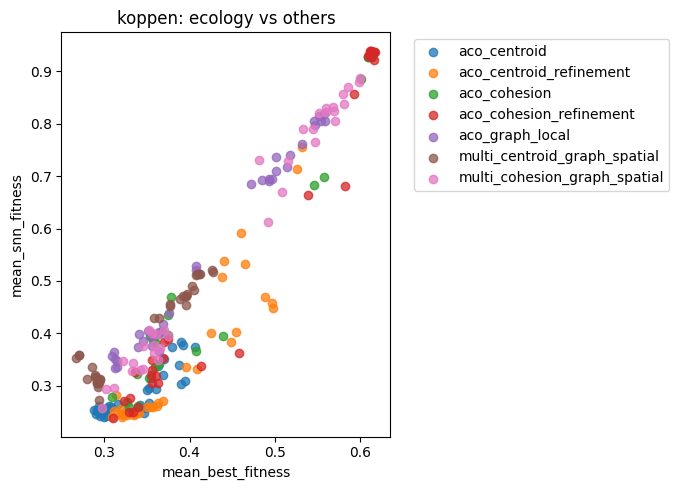

Pearson correlation


,mean_best_fitness,mean_snn_fitness,mean_ari_vs_kmeans
mean_best_fitness,1.000000,0.988504,-0.877479
mean_snn_fitness,0.988504,1.000000,-0.904248
mean_ari_vs_kmeans,-0.877479,-0.904248,1.000000


Spearman correlation


,mean_best_fitness,mean_snn_fitness,mean_ari_vs_kmeans
mean_best_fitness,1.000000,0.965204,-0.734414
mean_snn_fitness,0.965204,1.000000,-0.766396
mean_ari_vs_kmeans,-0.734414,-0.766396,1.000000


In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
for algorithm, subset in summary.groupby("algorithm"):
    ax.scatter(subset[FITNESS_COL], subset[OTHER_FUNCTION_1], label=algorithm, alpha=0.75)
ax.set_xlabel(FITNESS_COL)
ax.set_ylabel(OTHER_FUNCTION_2)
ax.set_title(f"{FEATURE_MODE}: ecology vs others")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Pearson correlation")
display(summary[[FITNESS_COL, OTHER_FUNCTION_2, ARI_COL]].corr(method="pearson"))
print("Spearman correlation")
display(summary[[FITNESS_COL, OTHER_FUNCTION_2, ARI_COL]].corr(method="spearman"))

## 10. Export analysis tables

In [ ]:
OUTPUT_DIR.mkdir(exist_ok=True)

tables = {
    "top5_by_fitness": top_by_fitness,
    "top5_by_ecology": top_by_ecology,
    "overall_config_distribution": overall_config_distribution,
    "overall_run_distribution": overall_run_distribution,
    "algorithm_means": algorithm_means,
    "parameter_means": parameter_means,
    "algorithm_distribution": algorithm_distribution,
    "parameter_distribution": parameter_distribution,
}

for name, table in tables.items():
    table.to_csv(OUTPUT_DIR / f"{FEATURE_MODE}_{name}.csv", index=False)

print("Saved analysis tables to:", OUTPUT_DIR)